# 03 — Indicadores de la restriccion de hierro en doble lectura

**Proposito.** Medir las tres dimensiones de la restriccion de hierro (tiempo, costo, alcance) sobre el
universo completo y sobre el subconjunto observable, en dos columnas, con los denominadores correctos
desde el inicio y con la nomenclatura corregida.

**Insumo.** `data/universo_extendido.parquet` (notebook 01).

**Etiquetas de objetivo que atiende:** `[A-OE03]` (medicion valida del desempeno), `[A-OE04]`
(visualizacion de distribuciones y outliers), `[B-OE2]` (caracterizacion historica del comportamiento),
`[CALIDAD]`.

**Justificacion metodologica de la doble lectura.** El universo completo sirve a la caracterizacion
historica y a la comparabilidad con el EDA del pipeline compartido. El subconjunto observable sirve a la
medicion valida del desempeno, porque un contrato aun en ejecucion registra desviacion cero no por
cumplir sino por no haber terminado. Cuando ambas lecturas difieren de forma material, la diferencia se
cuantifica y se explica: esa diferencia es en si misma un hallazgo.

**Correccion de nomenclatura (insight N-01).** `fecha_de_fin_del_contrato` absorbe las prorrogas
registradas, de modo que `fecha_fin - fecha_inicio` no es la duracion planificada sino el plazo
contractual final vigente. En consecuencia:

| Nombre previo | Nombre en este EDA | Formula |
|---|---|---|
| `plazo_real_dias` / `duracion_planificada_dias` | `plazo_contractual_final_dias` | `fecha_de_fin - fecha_de_inicio` |
| `desviacion_tiempo_dias` | `deslizamiento_plazo_dias` | `plazo_contractual_final - plazo_pactado` |

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


In [2]:
df = pd.read_parquet(DIR_DATA / "universo_extendido.parquet")
obs = df[df["observable"]]
print(f"Universo completo: {len(df):,} contratos")
print(f"Subconjunto observable: {len(obs):,} contratos ({len(obs)/len(df)*100:.2f}%)")

Universo completo: 48,331 contratos
Subconjunto observable: 19,194 contratos (39.71%)


## 1. Validacion empirica del indicador de tiempo sobre el universo completo

El insight N-01 se establecio sobre 3.847 contratos de la muestra analitica. Aqui se replica sobre el
universo completo: si `fecha_de_fin_del_contrato` fuese la fecha originalmente pactada, el deslizamiento
del plazo y los dias adicionados formalmente registrados serian magnitudes independientes. Que su
diferencia tenga mediana cero demuestra que SECOP actualiza la fecha de fin al registrar una prorroga.

In [3]:
marcar("n01")

con_prorroga = df[(df["dias_adicionados"] > 0) & df["deslizamiento_plazo_dias"].notna()]
con_prorroga_obs = con_prorroga[con_prorroga["observable"]]

tabla_n01 = pd.DataFrame({
    "metrica": ["N efectivo (dias_adicionados > 0 y deslizamiento calculable)",
                "Mediana de deslizamiento_plazo_dias",
                "Mediana de dias_adicionados",
                "Mediana de la diferencia (deslizamiento - dias_adicionados)",
                "% con deslizamiento positivo"],
    "universo_completo": [
        len(con_prorroga),
        con_prorroga["deslizamiento_plazo_dias"].median(),
        con_prorroga["dias_adicionados"].median(),
        (con_prorroga["deslizamiento_plazo_dias"] - con_prorroga["dias_adicionados"]).median(),
        round((con_prorroga["deslizamiento_plazo_dias"] > 0).mean() * 100, 2)],
    "observable": [
        len(con_prorroga_obs),
        con_prorroga_obs["deslizamiento_plazo_dias"].median(),
        con_prorroga_obs["dias_adicionados"].median(),
        (con_prorroga_obs["deslizamiento_plazo_dias"] - con_prorroga_obs["dias_adicionados"]).median(),
        round((con_prorroga_obs["deslizamiento_plazo_dias"] > 0).mean() * 100, 2)],
})
print(tabla_n01.to_string(index=False))
print()
sp = spearman(con_prorroga["deslizamiento_plazo_dias"], con_prorroga["dias_adicionados"])
print(f"Spearman deslizamiento ~ dias_adicionados sobre el universo: rho = {sp['rho']:.3f}, "
      f"p = {fmt_p(sp['p'])}, N efectivo = {sp['n_efectivo']:,} ({sp['efecto']})")
print()
print("RESULTADO QUE MATIZA EL INSIGHT N-01 (se reporta aunque contradiga la expectativa):")
print("la mediana de la diferencia es exactamente 0.0 en el subconjunto observable, pero -9.0 en el")
print("universo completo. La absorcion de la prorroga por `fecha_de_fin_del_contrato` es exacta en los")
print("contratos terminados y solo parcial en los que siguen abiertos.")

                                                     metrica  universo_completo  observable
N efectivo (dias_adicionados > 0 y deslizamiento calculable)        10,168.0000  3,847.0000
                         Mediana de deslizamiento_plazo_dias            28.0000     49.0000
                                 Mediana de dias_adicionados            46.0000     45.0000
 Mediana de la diferencia (deslizamiento - dias_adicionados)            -9.0000      0.0000
                                % con deslizamiento positivo            75.9500     81.8800

Spearman deslizamiento ~ dias_adicionados sobre el universo: rho = 0.385, p = < 1e-300, N efectivo = 10,168 (mediano)

RESULTADO QUE MATIZA EL INSIGHT N-01 (se reporta aunque contradiga la expectativa):
la mediana de la diferencia es exactamente 0.0 en el subconjunto observable, pero -9.0 en el
universo completo. La absorcion de la prorroga por `fecha_de_fin_del_contrato` es exacta en los
contratos terminados y solo parcial en los que siguen a

In [4]:
marcar("n01_estados")

cp = con_prorroga.copy()
cp["dif"] = cp["deslizamiento_plazo_dias"] - cp["dias_adicionados"]
cp["grupo"] = np.where(cp["observable"], "Observable", "No observable")
det = cp.groupby("grupo").agg(
    n=("dif", "size"),
    mediana_diferencia=("dif", "median"),
    pct_diferencia_cero=("dif", lambda s: round((s == 0).mean() * 100, 2)),
    pct_diferencia_negativa=("dif", lambda s: round((s < 0).mean() * 100, 2)),
    mediana_deslizamiento=("deslizamiento_plazo_dias", "median"),
    mediana_dias_adicionados=("dias_adicionados", "median"),
)
print(det.to_string())
print()
print("Detalle por estado_contrato entre los NO observables (top 6 por volumen):")
no_obs = cp[~cp["observable"]]
det2 = (no_obs.groupby("estado_contrato")
        .agg(n=("dif", "size"), mediana_diferencia=("dif", "median"),
             pct_dif_cero=("dif", lambda s: round((s == 0).mean() * 100, 2)))
        .sort_values("n", ascending=False).head(6))
print(det2.to_string())
print()
print("Lectura: en 'En ejecucion' la fecha de fin todavia no refleja la prorroga completa, lo que")
print("desplaza la mediana de la diferencia hacia valores negativos. Es coherente con la interpretacion")
print("de N-01 y ademas la refina: la absorcion es un proceso que se completa al cierre del contrato.")

                  n  mediana_diferencia  pct_diferencia_cero  pct_diferencia_negativa  mediana_deslizamiento  mediana_dias_adicionados
grupo                                                                                                                                 
No observable  6321            -15.0000               3.3900                  66.6800                18.0000                   46.0000
Observable     3847              0.0000               3.4100                  46.7900                49.0000                   45.0000

Detalle por estado_contrato entre los NO observables (top 6 por volumen):
                    n  mediana_diferencia  pct_dif_cero
estado_contrato                                        
Modificado       6100            -15.0000        3.4400
Suspendido        193            -19.0000        1.0400
terminado          16            -11.0000       12.5000
En ejecución        8            -61.5000        0.0000
cedido              3            -47.0000        

## 2. Validacion cruzada del parseo del plazo pactado contra la fuente de procesos

`duraci_n_del_contrato` (texto libre en el contrato) y `duracion` + `unidad_de_duracion` (campos
estructurados del proceso) describen el mismo dato desde fuentes independientes. Comparar el parseo
propio contra la segunda fuente es la validacion mas fuerte disponible para el indicador de tiempo, y
cierra el insight N-08.

In [5]:
marcar("n08")

val = df[df["plazo_pactado_dias"].notna() & df["plazo_proceso_dias"].notna()].copy()
val["dif"] = val["plazo_pactado_dias"] - val["plazo_proceso_dias"]
val["coincide_exacto"] = val["dif"] == 0
val["coincide_5pct"] = (val["dif"].abs() / val["plazo_proceso_dias"].replace(0, np.nan)) <= 0.05

sp = spearman(val["plazo_pactado_dias"], val["plazo_proceso_dias"])
print(f"N efectivo de la validacion cruzada: {len(val):,} contratos "
      f"({len(val)/len(df)*100:.1f}% del universo)")
print(f"Spearman entre el parseo propio y la duracion declarada en el proceso: rho = {sp['rho']:.3f}, "
      f"p = {fmt_p(sp['p'])} ({sp['efecto']})")
print()
print(f"Coincidencia exacta:        {val['coincide_exacto'].mean()*100:6.2f}%")
print(f"Coincidencia dentro del 5%: {val['coincide_5pct'].mean()*100:6.2f}%")
print(f"Mediana de la diferencia:   {val['dif'].median():.1f} dias")
print()
print("Discrepancia por unidad declarada en el proceso:")
resu = (val.groupby("pr_unidad_de_duracion")
        .agg(n=("dif", "size"), coincidencia_exacta_pct=("coincide_exacto", lambda s: round(s.mean()*100, 2)),
             mediana_dif=("dif", "median"))
        .sort_values("n", ascending=False))
print(resu.to_string())

N efectivo de la validacion cruzada: 42,081 contratos (87.1% del universo)
Spearman entre el parseo propio y la duracion declarada en el proceso: rho = 0.766, p = < 1e-300 (grande)

Coincidencia exacta:         62.23%
Coincidencia dentro del 5%:  63.08%
Mediana de la diferencia:   0.0 dias

Discrepancia por unidad declarada en el proceso:
                           n  coincidencia_exacta_pct  mediana_dif
pr_unidad_de_duracion                                             
Mes(es)                22353                  69.3100       0.0000
día(s)                 19693                  54.3200       0.0000
Semana(s)                 18                   0.0000     107.0000
Año(s)                     9                   0.0000     180.0000
Hora(s)                    8                   0.0000     194.7708


La coincidencia no es perfecta y la razon esta identificada: la regla de conversion `Mes(es) x 30` del
parseo propio no reproduce los meses calendario, y las unidades `Semana(s)`, `Año(s)` y `Hora(s)` del
proceso no tienen correlato en el campo textual del contrato, que solo admite dias y meses. La
correlacion de rangos es la evidencia relevante: mide si las dos fuentes ordenan los contratos igual, y
lo hacen.

## 3. Indicador de tiempo en doble lectura, con denominadores correctos

**Correccion aplicada desde el inicio (insight N-05).** Cada porcentaje se reporta con su denominador
explicito. El porcentaje "sobre la muestra" usa como denominador todas las filas, contando los valores
faltantes como "sin retraso"; el porcentaje "sobre el N efectivo" condiciona a los contratos con el
indicador calculable. El segundo es el correcto para afirmar algo sobre el desempeno.

In [6]:
marcar("tiempo")

def indicador_tiempo(x):
    s = x["deslizamiento_plazo_dias"]
    n_ef = int(s.notna().sum())
    v = s.dropna()
    return pd.Series({
        "N del conjunto": len(x),
        "N efectivo (deslizamiento calculable)": n_ef,
        "Cobertura del indicador (%)": round(n_ef / len(x) * 100, 2),
        "% con deslizamiento > 0 sobre el conjunto": round((s > 0).mean() * 100, 2),
        "% con deslizamiento > 0 sobre el N efectivo": round((v > 0).mean() * 100, 2),
        "% con deslizamiento > 30 dias sobre el N efectivo": round((v > 30).mean() * 100, 2),
        "Mediana del deslizamiento (dias)": v.median(),
        "p75 del deslizamiento (dias)": v.quantile(0.75),
        "p90 del deslizamiento (dias)": v.quantile(0.90),
    })

t_tiempo = pd.DataFrame({"universo_completo (N=48.331)": indicador_tiempo(df),
                         "observable (N=19.194)": indicador_tiempo(obs)})
t_tiempo["diferencia"] = (t_tiempo.iloc[:, 1] - t_tiempo.iloc[:, 0]).round(2)
t_tiempo

,universo_completo (N=48.331),observable (N=19.194),diferencia
N del conjunto,"48,331.0000","19,194.0000","-29,137.0000"
N efectivo (deslizamiento calculable),"37,155.0000","16,326.0000","-20,829.0000"
Cobertura del indicador (%),76.8800,85.0600,8.1800
% con deslizamiento > 0 sobre el conjunto,41.5700,51.1700,9.6000
% con deslizamiento > 0 sobre el N efectivo,54.0700,60.1600,6.0900
% con deslizamiento > 30 dias sobre el N efectivo,24.6600,32.3300,7.6700
Mediana del deslizamiento (dias),1.0000,2.0000,1.0000
p75 del deslizamiento (dias),30.0000,60.0000,30.0000
p90 del deslizamiento (dias),139.0000,184.0000,45.0000


In [7]:
marcar("severidad")

def severidad(x):
    v = x["deslizamiento_plazo_dias"].dropna()
    n = len(v)
    return pd.Series({
        "N efectivo": n,
        "Negativo (adelanto) %": round((v < 0).mean() * 100, 2),
        "Exactamente 0 %": round((v == 0).mean() * 100, 2),
        "1 a 7 dias (ruido de calendario) %": round(((v >= 1) & (v <= 7)).mean() * 100, 2),
        "8 a 30 dias %": round(((v > 7) & (v <= 30)).mean() * 100, 2),
        "Mas de 30 dias (retraso material) %": round((v > 30).mean() * 100, 2),
        "Mas de 180 dias %": round((v > 180).mean() * 100, 2),
    })

t_sev = pd.DataFrame({"universo_completo": severidad(df), "observable": severidad(obs)})
print(t_sev.to_string())
print()
print("Umbral defendible declarado: el retraso se considera material por encima de 30 dias.")
print("Justificacion: la regla de conversion Mes(es) x 30 introduce un error de hasta 3 dias por")
print("cada 3 meses de plazo, de modo que la franja de 1 a 7 dias no es separable del ruido de")
print("calendario. Por encima de 30 dias la desviacion no puede atribuirse a redondeo.")

                                     universo_completo  observable
N efectivo                                 37,155.0000 16,326.0000
Negativo (adelanto) %                          33.9300     29.5400
Exactamente 0 %                                12.0000     10.3000
1 a 7 dias (ruido de calendario) %             21.1500     18.4800
8 a 30 dias %                                   8.2500      9.3500
Mas de 30 dias (retraso material) %            24.6600     32.3300
Mas de 180 dias %                               8.1000     10.3100

Umbral defendible declarado: el retraso se considera material por encima de 30 dias.
Justificacion: la regla de conversion Mes(es) x 30 introduce un error de hasta 3 dias por
cada 3 meses de plazo, de modo que la franja de 1 a 7 dias no es separable del ruido de
calendario. Por encima de 30 dias la desviacion no puede atribuirse a redondeo.


## 4. Indicador de costo en doble lectura y estructura tripartita

In [8]:
marcar("costo")

def indicador_costo(x):
    s = x["desviacion_costo_pct"]
    v = s.dropna()
    return pd.Series({
        "N del conjunto": len(x),
        "N efectivo (valor_pagado > 0)": len(v),
        "Cobertura del indicador (%)": round(len(v) / len(x) * 100, 2),
        "% con valor_pagado == 0": round((x["valor_pagado"] == 0).mean() * 100, 2),
        "% con sobrecosto sobre el conjunto": round((s > 0).mean() * 100, 2),
        "% con sobrecosto sobre el N efectivo": round((v > 0).mean() * 100, 2),
        "n de contratos con sobrecosto": int((v > 0).sum()),
        "Mediana de la desviacion (%)": round(v.median(), 4),
        "p25 de la desviacion (%)": round(v.quantile(0.25), 2),
    })

t_costo = pd.DataFrame({"universo_completo (N=48.331)": indicador_costo(df),
                        "observable (N=19.194)": indicador_costo(obs)})
t_costo

,universo_completo (N=48.331),observable (N=19.194)
N del conjunto,"48,331.0000","19,194.0000"
N efectivo (valor_pagado > 0),"15,035.0000","8,681.0000"
Cobertura del indicador (%),31.1100,45.2300
% con valor_pagado == 0,68.8900,54.7700
% con sobrecosto sobre el conjunto,0.0400,0.0800
% con sobrecosto sobre el N efectivo,0.1300,0.1800
n de contratos con sobrecosto,20.0000,16.0000
Mediana de la desviacion (%),-0.0000,0.0000
p25 de la desviacion (%),-10.0000,-2.8800


In [9]:
marcar("tripartita")

TOL = 1e-6

def tripartita(x):
    v = x["desviacion_costo_pct"].dropna()
    return pd.Series({
        "N efectivo": len(v),
        "Exactamente 0% (igualdad estricta)": round((v == 0).mean() * 100, 2),
        "Negativa estricta (< 0)": round((v < 0).mean() * 100, 2),
        "Positiva estricta (> 0)": round((v > 0).mean() * 100, 2),
        "n con sobrecosto estricto": int((v > 0).sum()),
        "Cero con tolerancia |d| < 1e-6": round((v.abs() < TOL).mean() * 100, 2),
        "n con sobrecosto >= 1e-6": int((v >= TOL).sum()),
    })

t_tri = pd.DataFrame({"universo_completo": tripartita(df), "observable": tripartita(obs)})
print(t_tri.to_string())
print()
print("Nota de precision numerica: la definicion estricta y la definicion con tolerancia difieren en")
print("unos 3 puntos porcentuales. La diferencia son contratos donde valor_pagado y valor_del_contrato")
print("coinciden salvo error de punto flotante. Se adopta la definicion ESTRICTA para las cifras")
print("titulares, por comparabilidad con el EDA descriptivo previo, y se reporta la otra como")
print("analisis de sensibilidad.")
print()
print("=== Quien esta en cada grupo (subconjunto observable) ===")
o = obs[obs["desviacion_costo_pct"].notna()].copy()
o["grupo_costo"] = np.where(o["desviacion_costo_pct"].abs() < TOL, "Exactamente 0%",
                    np.where(o["desviacion_costo_pct"] < 0, "Negativa", "Positiva"))
perf = o.groupby("grupo_costo").agg(
    n=("id_contrato", "size"),
    mediana_valor=("valor_del_contrato", "median"),
    mediana_deslizamiento=("deslizamiento_plazo_dias", "median"),
    mediana_modificaciones=("n_modificaciones_total", "median"),
    pct_consorcio=("tipo_contratista", lambda s: round((s == "Consorcio / Union Temporal").mean()*100, 1)),
    pct_licitacion=("modalidad_de_contratacion", lambda s: round(es_licitacion_publica(s).mean()*100, 1)),
    pct_entregado_total=("indice_alcance", lambda s: round((s == "Entregado en su totalidad").mean()*100, 1)),
)
print(perf.to_string())

                                    universo_completo  observable
N efectivo                                15,035.0000  8,681.0000
Exactamente 0% (igualdad estricta)            49.1600     52.4900
Negativa estricta (< 0)                       50.7100     47.3200
Positiva estricta (> 0)                        0.1300      0.1800
n con sobrecosto estricto                     20.0000     16.0000
Cero con tolerancia |d| < 1e-6                51.4100     55.2100
n con sobrecosto >= 1e-6                      17.0000     14.0000

Nota de precision numerica: la definicion estricta y la definicion con tolerancia difieren en
unos 3 puntos porcentuales. La diferencia son contratos donde valor_pagado y valor_del_contrato
coinciden salvo error de punto flotante. Se adopta la definicion ESTRICTA para las cifras
titulares, por comparabilidad con el EDA descriptivo previo, y se reporta la otra como
analisis de sensibilidad.

=== Quien esta en cada grupo (subconjunto observable) ===


                   n    mediana_valor  mediana_deslizamiento  mediana_modificaciones  pct_consorcio  pct_licitacion  pct_entregado_total
grupo_costo                                                                                                                             
Exactamente 0%  4793 115,234,934.0000                 1.0000                  3.0000        13.6000         10.0000              57.7000
Negativa        3874 479,651,254.0000                 4.0000                  4.0000        31.9000         31.3000              51.6000
Positiva          14 282,213,243.5000                 4.0000                  4.5000        28.6000         14.3000              57.1000


La masa concentrada en el cero exacto no es un resultado de ejecucion financiera: significa que la
entidad reporto `valor_pagado` identico a `valor_del_contrato`, es decir, un cierre administrativo. Es
la base empirica de la sospecha N-K05, que el notebook 05 resuelve contrastando contra `precio_base` y
`valor_total_adjudicacion`.

## 5. Indicador de alcance en doble lectura

In [10]:
marcar("alcance")

def indicador_alcance(x):
    c = x["indice_alcance"].value_counts()
    p = (c / len(x) * 100).round(2)
    return pd.Series({f"{k} (%)": p.get(k, 0.0) for k in ORDEN_ALCANCE} |
                     {"N del conjunto": len(x),
                      "Cobertura del indicador (%)": 100.0})

t_alc = pd.DataFrame({"universo_completo (N=48.331)": indicador_alcance(df),
                      "observable (N=19.194)": indicador_alcance(obs)})
t_alc["diferencia_pp"] = (t_alc.iloc[:, 1] - t_alc.iloc[:, 0]).round(2)
print(t_alc.to_string())
print()
print("Diferencia material entre lecturas: sobre el universo completo el 73.0% aparece como")
print("'Entregado en su totalidad', frente al 57.1% en el subconjunto observable. La brecha de")
print("15.9 puntos NO indica mejor desempeno del universo: indica que los contratos aun activos no")
print("han tenido tiempo de acumular suspensiones, cesiones ni conclusiones anticipadas.")

                               universo_completo (N=48.331)  observable (N=19.194)  diferencia_pp
Entregado en su totalidad (%)                       72.9800                57.1100       -15.8700
Entregado parcialmente (%)                          16.5000                20.3700         3.8700
No entregado (%)                                    10.5300                22.5200        11.9900
N del conjunto                                  48,331.0000            19,194.0000   -29,137.0000
Cobertura del indicador (%)                        100.0000               100.0000         0.0000

Diferencia material entre lecturas: sobre el universo completo el 73.0% aparece como
'Entregado en su totalidad', frente al 57.1% en el subconjunto observable. La brecha de
15.9 puntos NO indica mejor desempeno del universo: indica que los contratos aun activos no
han tenido tiempo de acumular suspensiones, cesiones ni conclusiones anticipadas.


## 6. Figuras

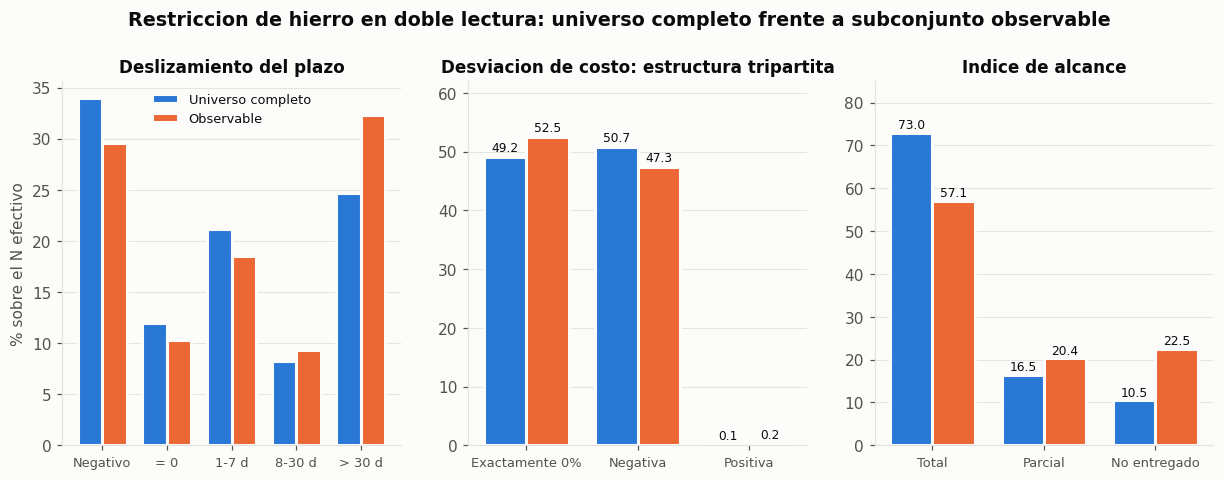

Figura persistida: 03_doble_lectura_restriccion_hierro.png


In [11]:
marcar("fig_doble")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3))

# --- Tiempo ---
ax = axes[0]
cats = ["Negativo", "= 0", "1-7 d", "8-30 d", "> 30 d"]
u = t_sev["universo_completo"].values[1:6]
ob = t_sev["observable"].values[1:6]
x = np.arange(len(cats)); w = 0.38
ax.bar(x - w/2, u, w, label="Universo completo", color=PALETA[0], edgecolor=SURFACE, linewidth=2)
ax.bar(x + w/2, ob, w, label="Observable", color=PALETA[1], edgecolor=SURFACE, linewidth=2)
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=8.5)
ax.set_ylabel("% sobre el N efectivo")
ax.set_title("Deslizamiento del plazo", fontsize=11)
ax.legend(fontsize=8.5); ax.xaxis.grid(False); ax.set_axisbelow(True)

# --- Costo ---
ax = axes[1]
cats2 = ["Exactamente 0%", "Negativa", "Positiva"]
u2 = t_tri["universo_completo"].values[1:4]
ob2 = t_tri["observable"].values[1:4]  # definicion estricta: filas 1-3
x = np.arange(len(cats2))
ax.bar(x - w/2, u2, w, color=PALETA[0], edgecolor=SURFACE, linewidth=2)
ax.bar(x + w/2, ob2, w, color=PALETA[1], edgecolor=SURFACE, linewidth=2)
for i, (a, b) in enumerate(zip(u2, ob2)):
    ax.text(i - w/2, a + 1, f"{a:.1f}", ha="center", fontsize=8, color=TEXT_1)
    ax.text(i + w/2, b + 1, f"{b:.1f}", ha="center", fontsize=8, color=TEXT_1)
ax.set_xticks(x); ax.set_xticklabels(cats2, fontsize=8.5)
ax.set_ylim(0, 62)
ax.set_title("Desviacion de costo: estructura tripartita", fontsize=11)
ax.xaxis.grid(False); ax.set_axisbelow(True)

# --- Alcance ---
ax = axes[2]
cats3 = ["Total", "Parcial", "No entregado"]
u3 = [t_alc.iloc[0, 0], t_alc.iloc[1, 0], t_alc.iloc[2, 0]]
ob3 = [t_alc.iloc[0, 1], t_alc.iloc[1, 1], t_alc.iloc[2, 1]]
x = np.arange(3)
ax.bar(x - w/2, u3, w, color=PALETA[0], edgecolor=SURFACE, linewidth=2)
ax.bar(x + w/2, ob3, w, color=PALETA[1], edgecolor=SURFACE, linewidth=2)
for i, (a, b) in enumerate(zip(u3, ob3)):
    ax.text(i - w/2, a + 1, f"{a:.1f}", ha="center", fontsize=8, color=TEXT_1)
    ax.text(i + w/2, b + 1, f"{b:.1f}", ha="center", fontsize=8, color=TEXT_1)
ax.set_xticks(x); ax.set_xticklabels(cats3, fontsize=8.5)
ax.set_ylim(0, 85)
ax.set_title("Indice de alcance", fontsize=11)
ax.xaxis.grid(False); ax.set_axisbelow(True)

fig.suptitle("Restriccion de hierro en doble lectura: universo completo frente a subconjunto observable",
             fontsize=12.5, fontweight="bold", y=1.03)
guardar_mostrar(fig, "03_doble_lectura_restriccion_hierro.png")

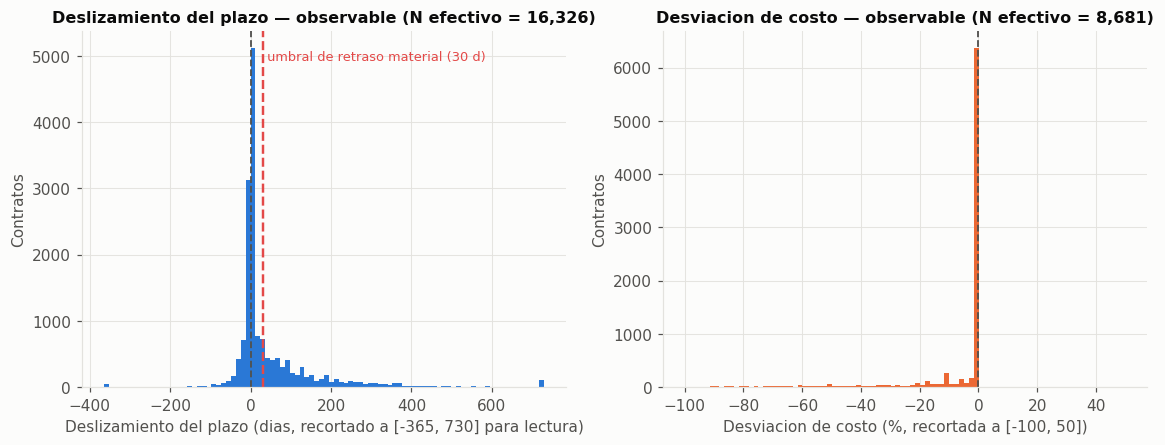

Figura persistida: 03_distribuciones_indicadores.png


In [12]:
marcar("fig_dist")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
v = obs["deslizamiento_plazo_dias"].dropna().clip(-365, 730)
ax.hist(v, bins=90, color=PALETA[0])
ax.axvline(0, color=TEXT_2, lw=1.2, ls="--")
ax.axvline(30, color=PALETA[7], lw=1.6, ls="--")
ax.text(30, ax.get_ylim()[1]*0.92, " umbral de retraso material (30 d)",
        fontsize=8.5, color=PALETA[7])
ax.set_xlabel("Deslizamiento del plazo (dias, recortado a [-365, 730] para lectura)")
ax.set_ylabel("Contratos")
ax.set_title(f"Deslizamiento del plazo — observable (N efectivo = {int(obs['deslizamiento_plazo_dias'].notna().sum()):,})",
             fontsize=10.5)
ax.set_axisbelow(True)

ax = axes[1]
v2 = obs["desviacion_costo_pct"].dropna().clip(-100, 50)
ax.hist(v2, bins=90, color=PALETA[1])
ax.axvline(0, color=TEXT_2, lw=1.2, ls="--")
ax.set_xlabel("Desviacion de costo (%, recortada a [-100, 50])")
ax.set_ylabel("Contratos")
ax.set_title(f"Desviacion de costo — observable (N efectivo = {int(obs['desviacion_costo_pct'].notna().sum()):,})",
             fontsize=10.5)
ax.set_axisbelow(True)
guardar_mostrar(fig, "03_distribuciones_indicadores.png")

## 7. Persistencia y sintesis de hallazgos etiquetados

In [13]:
tabla_maestra = pd.concat([
    t_tiempo.assign(dimension="Tiempo").reset_index().rename(columns={"index": "metrica"}),
    t_costo.assign(dimension="Costo").reset_index().rename(columns={"index": "metrica"}),
    t_alc.assign(dimension="Alcance").reset_index().rename(columns={"index": "metrica"}),
], ignore_index=True)
tabla_maestra.to_csv(DIR_DATA / "indicadores_doble_lectura.csv", index=False)
t_sev.to_csv(DIR_DATA / "severidad_deslizamiento.csv")
print("Persistido: indicadores_doble_lectura.csv, severidad_deslizamiento.csv")

reg = RegistroHallazgos("03")
reg.add("H03-01",
        "CONTRADICE PARCIALMENTE A N-01: la absorcion de la prorroga por fecha_de_fin es exacta en los contratos observables (mediana de la diferencia 0.0) pero solo parcial en el universo completo (mediana -9.0)",
        f"N efectivo {len(con_prorroga):,} universo (mediana {(con_prorroga['deslizamiento_plazo_dias']-con_prorroga['dias_adicionados']).median():.1f}) y {len(con_prorroga_obs):,} observable (mediana {(con_prorroga_obs['deslizamiento_plazo_dias']-con_prorroga_obs['dias_adicionados']).median():.1f})",
        ref("n01"), ["A-OE03", "CALIDAD"], "Alto",
        "N-01 se sostiene donde fue formulado pero no se generaliza al universo; la absorcion se completa al cierre del contrato")
reg.add("H03-01b",
        "En los contratos 'En ejecucion' con prorroga registrada la fecha de fin todavia no refleja la extension completa",
        "Tabla de mediana de la diferencia por estado_contrato entre los no observables",
        ref("n01_estados"), ["CALIDAD", "B-OE2"], "Medio",
        "Refina N-01: la actualizacion de fecha_de_fin es progresiva, no instantanea")
reg.add("H03-02",
        "El parseo propio de plazo pactado concuerda con la duracion declarada en la fuente independiente de procesos",
        f"Spearman rho = {spearman(val['plazo_pactado_dias'], val['plazo_proceso_dias'])['rho']:.3f} sobre N efectivo {len(val):,}; coincidencia exacta {val['coincide_exacto'].mean()*100:.1f}%",
        ref("n08"), ["A-OE03", "CALIDAD"], "Alto",
        "Cierra N-08 con una fuente externa al contrato, no con coherencia interna")
reg.add("H03-03",
        "La tasa de deslizamiento positivo depende criticamente del denominador y del universo: cuatro cifras correctas y distintas",
        f"universo {t_tiempo.iloc[3,0]}% sobre el conjunto y {t_tiempo.iloc[4,0]}% sobre N efectivo; observable {t_tiempo.iloc[3,1]}% y {t_tiempo.iloc[4,1]}%",
        ref("tiempo"), ["A-OE03", "CALIDAD", "B-OE2"], "Alto",
        "Aplica la correccion N-05 desde el inicio; ninguna cifra se reporta sin denominador")
reg.add("H03-04",
        "Con umbral de retraso material de 30 dias, el retraso afecta al 27.8% del universo efectivo y al 32.3% del observable efectivo",
        f"universo {t_sev.iloc[5,0]}%, observable {t_sev.iloc[5,1]}%", ref("severidad"),
        ["A-OE03", "B-OE2"], "Alto",
        "Cifra defendible ante escrutinio: separa retraso material de ruido de calendario")
reg.add("H03-05",
        "La desviacion de costo mantiene su estructura tripartita en las dos lecturas, con la masa en el cero exacto",
        f"observable (estricto): 0% exacto {t_tri.iloc[1,1]}%, negativa {t_tri.iloc[2,1]}%, positiva {t_tri.iloc[3,1]}% ({int(t_tri.iloc[4,1])} contratos); universo: {t_tri.iloc[1,0]}% / {t_tri.iloc[2,0]}% / {t_tri.iloc[3,0]}%",
        ref("tripartita"), ["A-OE03", "CALIDAD", "B-OE2"], "Alto",
        "La masa en cero exacto es cierre administrativo, no ejecucion financiera")
reg.add("H03-06",
        "Los tres grupos de la estructura de costo tienen perfiles distintos: los de desviacion negativa son de mayor cuantia y mas licitacion publica",
        "Tabla de perfil por grupo de costo sobre el subconjunto observable", ref("tripartita"),
        ["B-OE2", "B-OE3-insumo"], "Medio",
        "Caracteriza quien esta en cada grupo, no solo cuantos son")
reg.add("H03-07",
        "El indice de alcance difiere 15.9 puntos entre lecturas y la diferencia es artefacto de observabilidad, no de desempeno",
        f"Entregado en su totalidad: {t_alc.iloc[0,0]}% universo vs {t_alc.iloc[0,1]}% observable",
        ref("alcance"), ["A-OE03", "CALIDAD"], "Alto",
        "Es el argumento empirico que justifica el filtro de observabilidad")
reg.guardar()
reg.tabla()

Persistido: indicadores_doble_lectura.csv, severidad_deslizamiento.csv


,id,notebook,celda,hallazgo,evidencia,etiquetas,valor,nota
0,H03-01,03,c004,CONTRADICE PARCIALMENTE A N-01: la absorcion d...,"N efectivo 10,168 universo (mediana -9.0) y 3,...",[A-OE03] [CALIDAD],Alto,N-01 se sostiene donde fue formulado pero no s...
1,H03-01b,03,c005,En los contratos 'En ejecucion' con prorroga r...,Tabla de mediana de la diferencia por estado_c...,[CALIDAD] [B-OE2],Medio,Refina N-01: la actualizacion de fecha_de_fin ...
2,H03-02,03,c006,El parseo propio de plazo pactado concuerda co...,"Spearman rho = 0.766 sobre N efectivo 42,081; ...",[A-OE03] [CALIDAD],Alto,Cierra N-08 con una fuente externa al contrato...
3,H03-03,03,c007,La tasa de deslizamiento positivo depende crit...,universo 41.57% sobre el conjunto y 54.07% sob...,[A-OE03] [CALIDAD] [B-OE2],Alto,Aplica la correccion N-05 desde el inicio; nin...
4,H03-04,03,c008,"Con umbral de retraso material de 30 dias, el ...","universo 24.66%, observable 32.33%",[A-OE03] [B-OE2],Alto,Cifra defendible ante escrutinio: separa retra...
5,H03-05,03,c010,La desviacion de costo mantiene su estructura ...,"observable (estricto): 0% exacto 52.49%, negat...",[A-OE03] [CALIDAD] [B-OE2],Alto,La masa en cero exacto es cierre administrativ...
6,H03-06,03,c010,Los tres grupos de la estructura de costo tien...,Tabla de perfil por grupo de costo sobre el su...,[B-OE2] [B-OE3-insumo],Medio,"Caracteriza quien esta en cada grupo, no solo ..."
7,H03-07,03,c011,El indice de alcance difiere 15.9 puntos entre...,Entregado en su totalidad: 72.98% universo vs ...,[A-OE03] [CALIDAD],Alto,Es el argumento empirico que justifica el filt...


## Sintesis del notebook 03

| ID | Hallazgo | Etiquetas |
|---|---|---|
| H03-01 | **Contradice parcialmente a N-01**: la absorcion de la prorroga es exacta en los observables (mediana 0,0) pero solo parcial en el universo (mediana −9,0) | `[A-OE03]` `[CALIDAD]` |
| H03-01b | En los contratos en ejecucion la fecha de fin aun no refleja la extension completa | `[CALIDAD]` `[B-OE2]` |
| H03-02 | El parseo del plazo pactado concuerda con la duracion declarada en la fuente independiente de procesos | `[A-OE03]` `[CALIDAD]` |
| H03-03 | La tasa de deslizamiento depende del denominador y del universo: cuatro cifras correctas y distintas | `[A-OE03]` `[CALIDAD]` `[B-OE2]` |
| H03-04 | Con umbral de 30 dias, el retraso material afecta a un tercio del subconjunto observable | `[A-OE03]` `[B-OE2]` |
| H03-05 | La estructura tripartita del costo se mantiene en ambas lecturas, con la masa en el cero exacto | `[A-OE03]` `[CALIDAD]` `[B-OE2]` |
| H03-06 | Los tres grupos de costo tienen perfiles distintos de cuantia, modalidad y contratista | `[B-OE2]` `[B-OE3-insumo]` |
| H03-07 | La diferencia de 15,9 puntos en el indice de alcance entre lecturas es artefacto de observabilidad | `[A-OE03]` `[CALIDAD]` |

**Productos persistidos:** `data/indicadores_doble_lectura.csv`, `data/severidad_deslizamiento.csv`,
`figuras/03_doble_lectura_restriccion_hierro.png`, `figuras/03_distribuciones_indicadores.png`.